CNN 활용한 이미지 인식

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

세션 다시 시작 후 진행

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [2]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [3]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [4]:
# GPU 확인
# 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


CNN 처리 개요

In [5]:
data_root = './data'

# 샘플 손글씨 숫자 데이터 가져오기
transform = transforms.Compose([
            transforms.ToTensor()  # [0,1]
        ]
        )

train_set = datasets.MNIST(
            root=data_root,
            train=True,
            download=True,
            transform=transform
        )

train_set

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.45MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [6]:
image, label = train_set[0]
print(label)

5


In [7]:
image.shape # 3차원 (CHW, 흑백이미지, 28*28 사이즈 이미지)

torch.Size([1, 28, 28])

In [8]:
image = image.view(1,1,28,28)
image.shape

torch.Size([1, 1, 28, 28])

In [9]:
image[0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [10]:
# 대각선 상에만 가중치를 갖는 특수한 합성곱 함수를 만들어 볼게요

conv1 = nn.Conv2d(1,1,3) # 입력 채널: 1, 출력 채널: 1, 커널크기: 3*3

# bias = 0 으로 둠
nn.init.constant_(conv1.bias, 0.0)

# weight 를 특수한 값으로
w1_np = np.array([[0,0,1], [0,1,0], [1,0,0]])
w1=torch.tensor(w1_np).float()
print(w1)
print(w1.shape)

tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]])
torch.Size([3, 3])


In [11]:
w1 = w1.view(1,1,3,3)
w1

tensor([[[[0., 0., 1.],
          [0., 1., 0.],
          [1., 0., 0.]]]])

In [12]:
conv1.weight.data=w1

In [13]:
train_set[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [14]:
# 손글씨 숫자에 3번 합성곱 처리를 함
image, label = train_set[0]
image = image.view(1,1,28,28)
w1 = conv1(image)
w2 = conv1(w1)
w3 = conv1(w2)
images = [image,w1, w2, w3]
images

[tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0

In [15]:
images[0].data.numpy()

array([[[[0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ],
         [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ],
         [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ],
         [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
          0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       

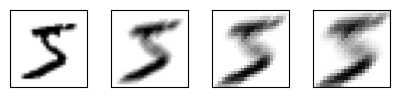

In [16]:
plt.figure(figsize=(5,1))
for i in range(4):
    size = 28 - i*2
    ax = plt.subplot(1,4, i+1)
    img = images[i].data.numpy()
    plt.imshow(img.reshape(size, size), cmap='gray_r')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# 원본이미지
# weight가 다르기때문에 특정 부분만 강하게 남는 이미지가 나옴.

파이토치에서 CNN 구현하는 법

In [18]:
# nn.Conv2d와 nn.MaxPool2d

conv1 = nn.Conv2d(3, 32, 3)  # 입력채널: 3(rgb), 출력채널: 32, 커널크기: 3*3
relu = nn.ReLU(inplace=True) # 활성화함수(activation function)
conv2 = nn.Conv2d(32, 32, 3) # 입력채널 : 32 -> conv1의 출력 채널. 커널크기 3*3
maxpool = nn.MaxPool2d((2,2))          # pooling 영역: 2*2

In [19]:
# conv1 확인
print(conv1)

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))


In [20]:
# conv1 내부 변수 shape 확인
print(f'conv1 weight shape: {conv1.weight.shape}')
# [출력 채널(특징맵) 수, 입력(입력된 데이터) 채널 수, 필터 높이, 필터 너비]
print(f'conv1 bias shape: {conv1.bias.shape}')
# [출력 채널 수] 가중치 계산 결과로 나온 편향 값 (출력 채널(특징맵) 수와 항상 일치)

conv1 weight shape: torch.Size([32, 3, 3, 3])
conv1 bias shape: torch.Size([32])


In [21]:
# conv2 내부 변수 shape 확인
print(f'conv2 weight shape: {conv2.weight.shape}')
# [출력 채널(특징맵) 수, 입력(입력된 데이터) 채널 수, 필터 높이, 필터 너비]
print(f'conv2 bias shape: {conv2.bias.shape}')
# [출력 채널 수] 가중치 계산 결과로 나온 편향 값 (출력 채널(특징맵) 수와 항상 일치)

conv2 weight shape: torch.Size([32, 32, 3, 3])
conv2 bias shape: torch.Size([32])


In [22]:
# conv1의 weight[0] 0번째 출력 채널의 가중치
w = conv1.weight[0]

print(w.shape)
print(w.data.numpy())

torch.Size([3, 3, 3])
[[[-0.0137  0.1807 -0.0234]
  [ 0.1256 -0.0597 -0.1285]
  [ 0.0142  0.0964  0.1603]]

 [[ 0.1349  0.099  -0.0143]
  [-0.0995 -0.     -0.1481]
  [-0.1723 -0.1757  0.1696]]

 [[-0.0315 -0.0698 -0.1183]
  [-0.1733 -0.0509  0.1049]
  [ 0.0446  0.1428 -0.1221]]]


In [23]:
# 더미로 입력과 같은 사이즈를 갖는 텐서 생성
inputs = torch.randn(100, 3, 32, 32)
print(inputs.shape)

torch.Size([100, 3, 32, 32])


In [24]:
# CNN 전반부 처리 시뮬레이션

x1 = conv1(inputs)
x2 = relu(x1)
x3 = conv2(x2)
x4 = relu(x3)
x5 = maxpool(x4)

In [26]:
# 각 변수의 shape 확인
print(inputs.shape)
print(x1.shape) # conv1 해서 size가 2씩 줄어듦 커널 사이즈 3*3
print(x2.shape) # ReLU
print(x3.shape) # conv3 해서 사이즈 2씩 줄어듦
print(x4.shape) # ReLU
print(x5.shape) # max_pooling -> 풀링 사이즈 2니까 사이즈 1/2 됨

torch.Size([100, 3, 32, 32])
torch.Size([100, 32, 30, 30])
torch.Size([100, 32, 30, 30])
torch.Size([100, 32, 28, 28])
torch.Size([100, 32, 28, 28])
torch.Size([100, 32, 14, 14])


nn.Sequential

In [30]:
# 함수정의
features = nn.Sequential( # 위에서 한걸 한번에 하기 위해서 시퀀스 씀. 익숙하죠?
    conv1,
    relu,
    conv2,
    relu,
    maxpool
)


In [31]:
# 동작 테스트
outputs=features(inputs)

# 결과
outputs.shape

torch.Size([100, 32, 14, 14])

nn.Flatten

In [35]:
# 함수 정의
flatten = nn.Flatten() # 벡터화

In [36]:
outputs2 = flatten(outputs)

# 결과 확인
print(f'Flatten 이전 shape: {outputs.shape}')
print(f'Flatten 이후 shape: {outputs2.shape}') # 6272 = 32 * 14 * 14

Flatten 이전 shape: torch.Size([100, 32, 14, 14])
Flatten 이후 shape: torch.Size([100, 6272])


# 공통 함수 사용하기

In [37]:
# eval_loss(손실계산)

def eval_loss(loader, device, net, criterion):
    for images, labels in loader:
        break

    # device 할당
    inputs = images.to(device)
    labels = labels.to(device)

    # 예측
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels)

    return loss

In [40]:
# fit(학습)
def fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history):
    from tqdm.notebook import tqdm

    base_epochs = len(history)

    for epoch in range(base_epochs, num_epochs+base_epochs):
        train_loss=0
        train_acc=0
        val_loss=0
        val_acc=0

        # 훈련용 모드
        net.train()
        count=0

        for inputs, labels in tqdm(train_loader):
            count += len(labels)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # 경사 초기화
            optimizer.zero_grad()
            # 예측
            outputs = net(inputs)
            # 손실계산
            loss = criterion(outputs, labels)
            train_loss += loss.item()
            # 경사 계산
            loss.backward()
            # 파라미터 수정
            optimizer.step()
            # 예측 라벨 산출
            predicted = torch.max(outputs, 1)[1]
            # 정답 건수 산출(acc)
            train_acc += (predicted == labels).sum().item()
            # 손실과 정확도 계산
            avg_train_loss = train_loss / count
            avg_train_acc = train_acc / count

        # 평가용 모드
        net.eval()
        count=0

        for inputs, labels in test_loader:
            count += len(labels)
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            predicted = torch.max(outputs, 1)[1]

            val_acc += (predicted==labels).sum().item()

            avg_val_loss = val_loss / count
            avg_val_acc = val_acc / count

        print (f'Epoch [{(epoch+1)}/{num_epochs+base_epochs}], loss: {avg_train_loss:.5f} acc: {avg_train_acc:.5f} val_loss: {avg_val_loss:.5f}, val_acc: {avg_val_acc:.5f}')
        item = np.array([epoch+1, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc])
        history = np.vstack((history, item))
    return history

In [41]:
# eval_history(학습 로그)

def evaluate_history(history):
    # 손실과 정확도 확인
    print(f'초기상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}')
    print(f'최종상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    # 학습 곡선 출력(손실)
    plt.figure(figsize=(9,8))
    plt.plot(history[:,0], history[:,1], 'b', label='훈련')
    plt.plot(history[:,0], history[:,3], 'k', label='검증')
    plt.xticks(np.arange(0,num_epochs+1, unit))
    plt.xlabel('반복 횟수')
    plt.ylabel('손실')
    plt.title('학습 곡선(손실)')
    plt.legend()
    plt.show()

    # 학습 곡선 출력(정확도)
    plt.figure(figsize=(9,8))
    plt.plot(history[:,0], history[:,2], 'b', label='훈련')
    plt.plot(history[:,0], history[:,4], 'k', label='검증')
    plt.xticks(np.arange(0,num_epochs+1,unit))
    plt.xlabel('반복 횟수')
    plt.ylabel('정확도')
    plt.title('학습 곡선(정확도)')
    plt.legend()
    plt.show()

In [42]:
# show_images_labels (예측결과 표시)

# 이미지와 라벨 표시
def show_images_labels(loader, classes, net, device):
    # 데이터 로더에서 처음 1세트 가져오기
    for images, labels in loader:
        break
    # 표시 수는 50개
    n_size = min(len(images), 50)

    if net is not None:
        inputs = images.to(device)
        labels = labels.to(device)

        # 예측 계산
        outputs = net(inputs)
        predicted = torch.max(outputs, 1)[1]

    # 처음 n_size개 표시
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # net이 None이 아닌 경우는 예측 결과도 타이틀에 표시함
        if net is not None:
          predicted_name = classes[predicted[i]]
          # 정답인지 아닌지 색으로 구분함
          if label_name == predicted_name:
            c = 'k'
          else:
            c = 'b'
          ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # net이 None인 경우는 정답 라벨만 표시
        else:
          ax.set_title(label_name, fontsize=20)
        # 텐서를 넘파이로 변환
        image_np = images[i].numpy().copy()
        # 축의 순서 변경 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0)) # numpy로 바꿔서 순서 바꾸기.

                                                # pytorch 는 h,w,c이다!
                                                # 이유는 각각은 원래 하나인데
                                                # gpu에서 병렬로 처리하기 위해서 나눈거다.
                                                # numpy cpu이기 때문에 원래인 c,h,w로 복구해줘야 됨.


        # 값의 범위를[-1, 1] -> [0, 1]로 되돌림
        img = (img + 1)/2
        # 결과 표시
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()


In [ ]:
        # 텐서를 넘파이로 변환
        image_np = images[i].numpy().copy()
        # 축의 순서 변경 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0)) # numpy로 바꿔서 순서 바꾸기.
        # 값의 범위를[-1, 1] -> [0, 1]로 되돌림
        img = (img + 1)/2

        # 이게 중요한 부분 반드시 쳐봐야 한대요.

In [ ]:
image_np = imgaes[i].numpy().copy()

img = np.transpose(image_np, (1,2,0))

img = (img+1) /2

In [43]:
# 파이토치 난수 고정

def torch_seed(seed=123):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms = True

In [44]:
# 데이터 준비

# Transforms 정의

# transform1 : 1차원 텐서화 (전결합)
transform1 = transforms.Compose([
    transforms.ToTensor(),  # 넘파이 배열 >> 텐서로 변환 [0,1] 사이 # 기본이 [0 1] tan 활성화 함수가 안됨
    transforms.Normalize(0.5, 0.5), # 데이터를 [-1,1] 범위로 정규화 -> 중심이 0으로 오게하 기 위함.
                                                                    # 이게 결과가 더 좋음.
                                                                    # 모든 활성화 함수와 호환
                                                                    # 평균이 0이면 더 빠름.
    transforms.Lambda(lambda x: x.view(-1)) # 텐서를 1차원으로 평탄화
])

# transform2: 정규화만 실시(CNN용)
transform2 = transforms.Compose([
    transforms.ToTensor(),  # 넘파이 배열 >> 텐서로 변환 [0,1] 사이
    transforms.Normalize(0.5, 0.5), # 데이터를 [-1,1] 범위로 정규화
])

In [ ]:
# 데이터 준비 한번 쳐보기


# Transforms 정의

# transform1 : 1차원 텐서화 (전결합)

transform1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5),
    transforms.Lambda(lambda x : x.view(-1))
])

# transform2 : 정규화만 실시 -> CNN에서 사용할거임
transform1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5) # 여기까지 하는게 CNN용

])


In [45]:
# 데이터 취득용 함수 datasets

data_root = './data'

# 훈련 데이터셋 (1계 텐서 버전)
train_set1 = datasets.CIFAR10(
    root = data_root, train = True,
    download = True, transform = transform1)

# 검증 데이터셋 (1계 텐서 버전)
test_set1 = datasets.CIFAR10(
    root = data_root, train = False,
    download = True, transform = transform1)

# 훈련 데이터셋 (3계 텐서 버전)
train_set2 = datasets.CIFAR10(
    root =  data_root, train = True,
    download = True, transform = transform2)

# 검증 데이터셋 (3계 텐서 버전)
test_set2 = datasets.CIFAR10(
    root = data_root, train = False,
    download = True, transform = transform2)

100%|██████████| 170M/170M [00:06<00:00, 28.3MB/s]


# 데이터셋 확인

In [46]:
train_set1

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
               Lambda()
           )

In [49]:
train_set1[0]

(tensor([-0.5373, -0.6627, -0.6078,  ...,  0.0980, -0.3412, -0.4353]), 6)

In [50]:
image1, label1 = train_set1[0]
image2, label2 = train_set2[0]

print(image1.shape)
print(image2.shape)

torch.Size([3072])
torch.Size([3, 32, 32])


In [51]:
# 데이터로더 정의

# 미니 배치 사이즈 지정
batch_size = 100

# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정
train_loader1 = DataLoader(train_set1, batch_size=batch_size, shuffle=True)

# 검증용 데이터로더
# 검증용이므로 셔플하지 않음
test_loader1 = DataLoader(test_set1,  batch_size=batch_size, shuffle=False)

# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정
train_loader2 = DataLoader(train_set2, batch_size=batch_size, shuffle=True)

# 검증용 데이터로더
# 검증용이므로 셔플하지 않음
test_loader2 = DataLoader(test_set2,  batch_size=batch_size, shuffle=False)


In [52]:
for images1, labels1 in train_loader1:
    break

for images2, labels2 in train_loader2:
    break

print(images1.shape)
print(images2.shape)

torch.Size([100, 3072])
torch.Size([100, 3, 32, 32])


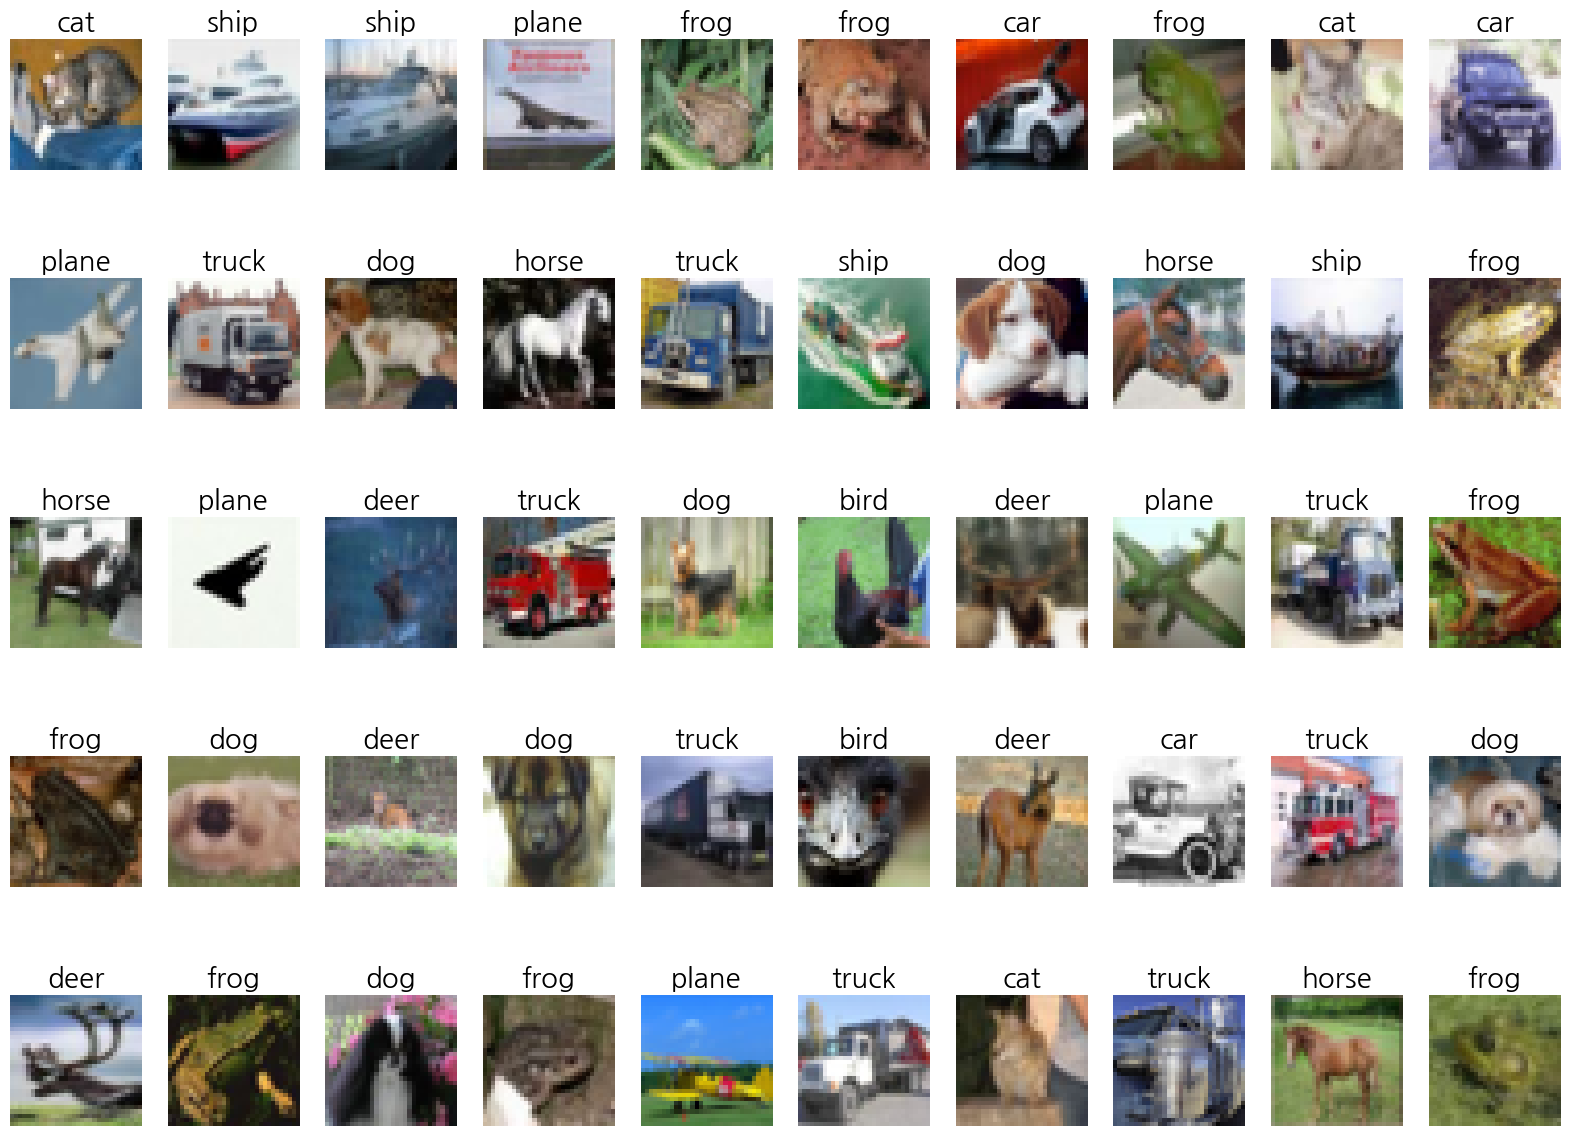

In [53]:
# 정답 라벨 정의
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 검증 데이터의 처음 50개를 출력
show_images_labels(test_loader2, classes, None, None)
# show_images_labels(검증용 데이터, 클래스 이름, 예측값, 모델 객체)

모델 정의(완전결합)

In [54]:
# 학습용 파라미터 설정

# 입력차원수 3*32*32=3072
image1.view(-1).shape

torch.Size([3072])

In [55]:
image1.view(-1).shape[0]

3072

In [56]:
# 입력 차원수
n_input = image1.view(-1).shape[0]

# 출력 차원수 (분류 클래스: 10)
# labels1
# labels1.data.numpy()
n_output = len(set(list(labels1.data.numpy())))

# 은닉층의 노드 수
n_hidden = 128

# 결과 확인
print(f'n_input: {n_input}')
print(f'n_output: {n_output}')
print(f'n_hidden: {n_hidden}')

n_input: 3072
n_output: 10
n_hidden: 128


In [ ]:
# 모델 정의
# 3072입력 10출력 1은닉층을 포함한 신경망 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        # 은닉층 정의(은닉층의 노드수 : n_hidden)
        self.l1 = nn.Linear(n_input, n_hidden)

        # 출력층의 정의
        self.l2 = nn.Linear(n_hidden, n_output)

        # ReLU 함수 정의
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        return x3

In [ ]:
net = Net(n_input, n_output, n_hidden).to(device)

# 손실함수 : 교차 엔트로피
criterion = nn.CrossEntropyLoss()

# 학습률
lr = 0.01

# 최적화함수
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [ ]:
print(net)

Net(
  (l1): Linear(in_features=3072, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU(inplace=True)
)


In [ ]:
summary(net, (100, 3072), depth=1)
# (100, 3072) : 배치크기, 입력되는 특성 수
# depth=1 : 최상위 레이어만 표시해줘 depth2, 3 더 자세히 보여줘

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [100, 10]                 --
├─Linear: 1-1                            [100, 128]                393,344
├─ReLU: 1-2                              [100, 128]                --
├─Linear: 1-3                            [100, 10]                 1,290
Total params: 394,634
Trainable params: 394,634
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 39.46
Input size (MB): 1.23
Forward/backward pass size (MB): 0.11
Params size (MB): 1.58
Estimated Total Size (MB): 2.92

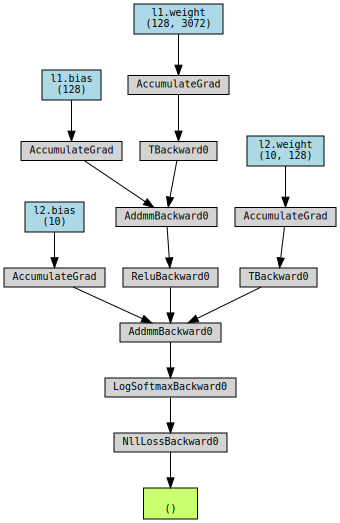

In [ ]:
# 손실 계산
loss = eval_loss(test_loader1, device, net, criterion)

# 손실 계산 그래프 시각화
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [ ]:
np.zeros((0,5))

array([], shape=(0, 5), dtype=float64)

In [ ]:
# 완전 결합형 모델 초기화와 학습
torch_seed() # 난수 초기화
net = Net(n_input, n_hidden, n_output).to(device)
criterion = nn.CrossEntropyLoss()

lr = 0.01
optimizer = optim.SGD(net.parameters(), lr=lr)
num_epochs = 50
history = np.zeros((0,5))

# 학습
history = fit(net, optimizer, criterion, num_epochs, train_loader1, test_loader1, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.02897 acc: 0.24314 val_loss: 0.02086, val_acc: 0.33230


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01970 acc: 0.34750 val_loss: 0.01891, val_acc: 0.36160


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.01560 acc: 0.44642 val_loss: 0.01623, val_acc: 0.41970


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.01558 acc: 0.44680 val_loss: 0.01624, val_acc: 0.42100


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.01557 acc: 0.44736 val_loss: 0.01625, val_acc: 0.41940


초기상태 : 손실 : 0.02086  정확도 : 0.33230
최종상태 : 손실 : 0.01625  정확도 : 0.41940


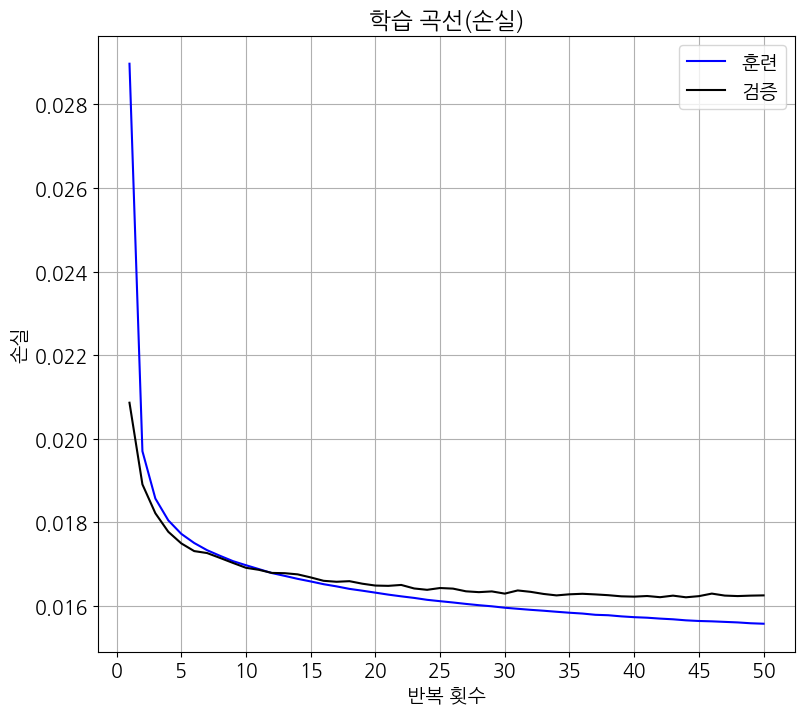

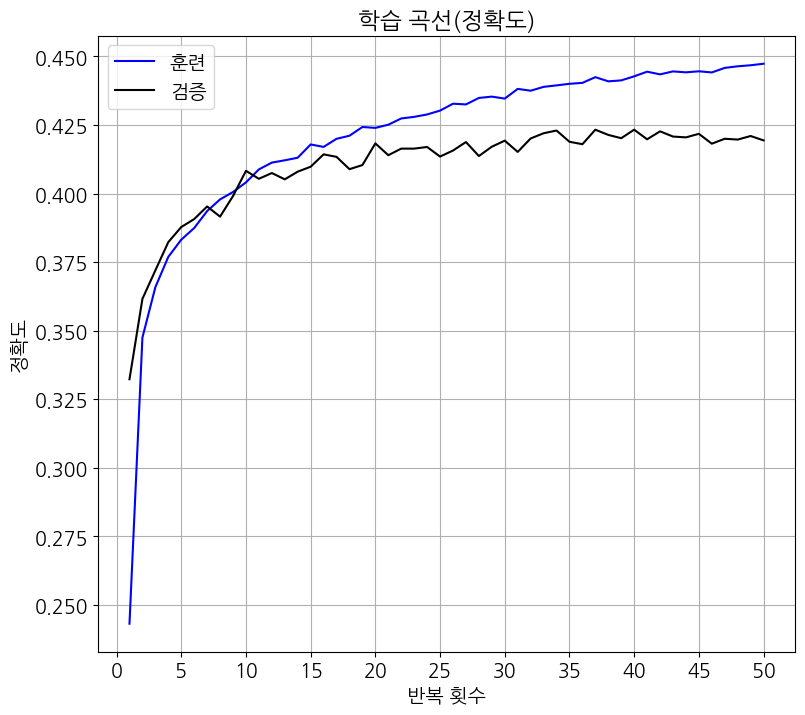

In [ ]:
# 평가
evaluate_history(history)

모델 정의(CNN)

In [61]:
class CNN(nn.Module):
    def __init__(self, n_output, n_hidden):
        super().__init__()
        # 레이어 정의
        # 특성 추출(feature extraction)
        self.conv1 = nn.Conv2d(3, 32, 3) # 입력채널(3, rgb) 출력채널(32), 커널: 3*3
        self.conv2 = nn.Conv2d(32, 32, 3)# 입력채널(32) 출력채널(32), 커널: 3*3
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d((2,2))

        # 분류기(classifier: clf)
        self.flatten = nn.Flatten()
        self.l1 = nn.Linear(6272, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_output)

        # 역할별로 그룹화
        self.features = nn.Sequential(
            self.conv1, self.relu, self.conv2, self.relu, self.maxpool
        )

        self.classifier = nn.Sequential(self.l1, self.relu, self.l2)

    # 조립 라인 : 데이터 흐름 정의
    def forward(self, x):
        x1 = self.features(x)    # 특징 추출
        x2 = self.flatten(x1)    # 1차원으로 쭉 펼치기
        x3 = self.classifier(x2) # 최종 분류
        return x3


In [57]:
# CNN 쳐보기

class CNN(nn.Module):
    def __init__(self, n_output, n_hidden):
        super().__init__()

        #레이어 정의
        #특성 추출 feature extraction
        self.conv1 = nn.Conv2d(3,32,3)
        self.conv2 = nn.Conv2d(32,32,3)
        self.relu = nn.ReLU(inplace = True)
        self.maxpool = nn.MaxPool2d((2,2))

        # 분류기 clf == classifier
        self.flatten = nn.Flatten()
        self.l1 = nn.Linear(6272, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_output)



        self.feature = nn.Sequential(
            self.conv1, self.relu, self.conv2, self.relu, self.maxpool
        )

        self.clf = nn.Sequential(
            self.l1,self.relu, self.l2
        )

    def forward(self, x):
        x1 = self.feature(x)  # 특징추출
        x2 = self.flatten(x1) # 1차원으로 펼치기
        x3 = self.clf(x2)     # 최종 분류
        return x3



In [62]:
# 모델 인스턴스 생성
net = CNN(n_output, n_hidden).to(device)

# 손실함수
criterion = nn.CrossEntropyLoss()

lr = 0.01
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [63]:
print(net)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Linear(in_features=6272, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=10, bias=True)
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=6272, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [64]:
summary(net, (100,3,32,32), depth=2)

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [100, 10]                 --
├─Sequential: 1-1                        [100, 32, 14, 14]         9,248
│    └─Conv2d: 2-1                       [100, 32, 30, 30]         896
├─Sequential: 1-4                        --                        (recursive)
│    └─ReLU: 2-2                         [100, 32, 30, 30]         --
├─Sequential: 1-5                        --                        (recursive)
│    └─Conv2d: 2-3                       [100, 32, 28, 28]         9,248
├─Sequential: 1-4                        --                        (recursive)
│    └─ReLU: 2-4                         [100, 32, 28, 28]         --
├─Sequential: 1-5                        --                        (recursive)
│    └─MaxPool2d: 2-5                    [100, 32, 14, 14]         --
├─Flatten: 1-6                           [100, 6272]               --
├─Sequential: 1-7                        [

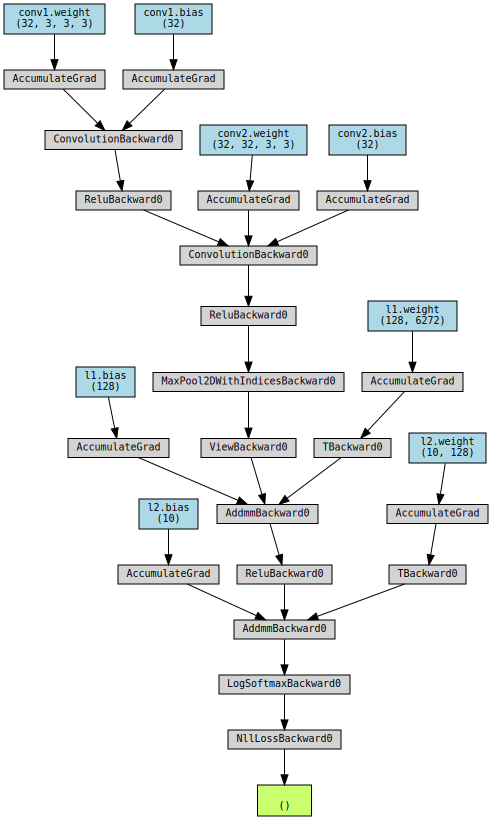

In [65]:
# 손실 계산
loss = eval_loss(test_loader2, device, net, criterion)

# 손실 계산 그래프 시각화
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [66]:
# CNN 모델 초기화와 학습
torch_seed() # 난수 초기화
net = CNN(n_output, n_hidden).to(device) # 모델 인스턴스 생성
criterion = nn.CrossEntropyLoss() # 손실 함수
lr = 0.01 # 학습률
optimizer = optim.SGD(net.parameters(), lr=lr) # 최적화 함수 : 경사 하강법
num_epochs = 50 # 반복 횟수
history2 = np.zeros((0, 5)) # 평가 결과 기록

# 학습
history2 = fit(net, optimizer, criterion, num_epochs, train_loader2, test_loader2, device, history2)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.02082 acc: 0.26096 val_loss: 0.01866, val_acc: 0.34720


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01781 acc: 0.37288 val_loss: 0.01677, val_acc: 0.40910


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00035 acc: 0.99674 val_loss: 0.01792, val_acc: 0.66430


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00029 acc: 0.99764 val_loss: 0.01860, val_acc: 0.66370


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00024 acc: 0.99868 val_loss: 0.01880, val_acc: 0.66140


초기상태 : 손실 : 0.01866  정확도 : 0.34720
최종상태 : 손실 : 0.01880  정확도 : 0.66140


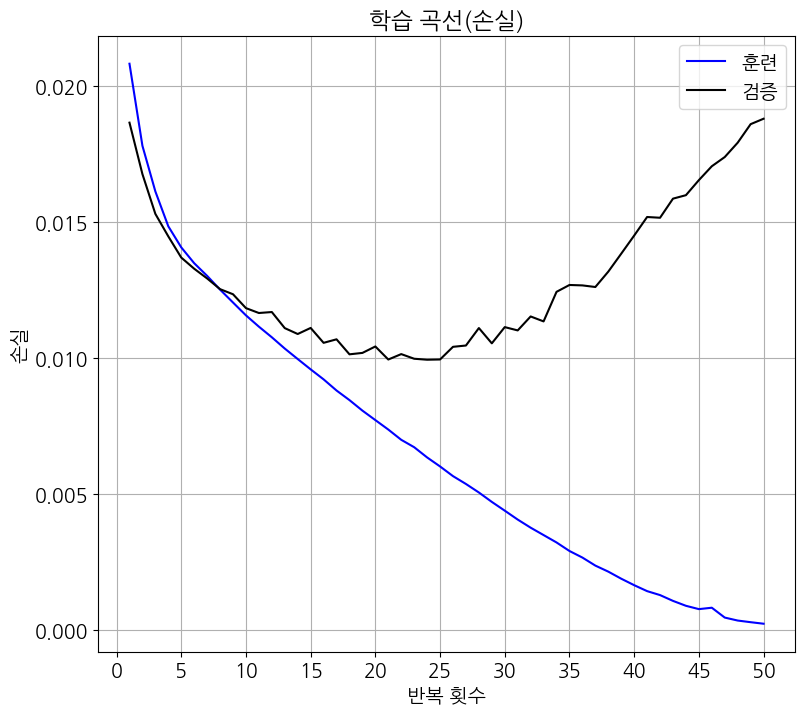

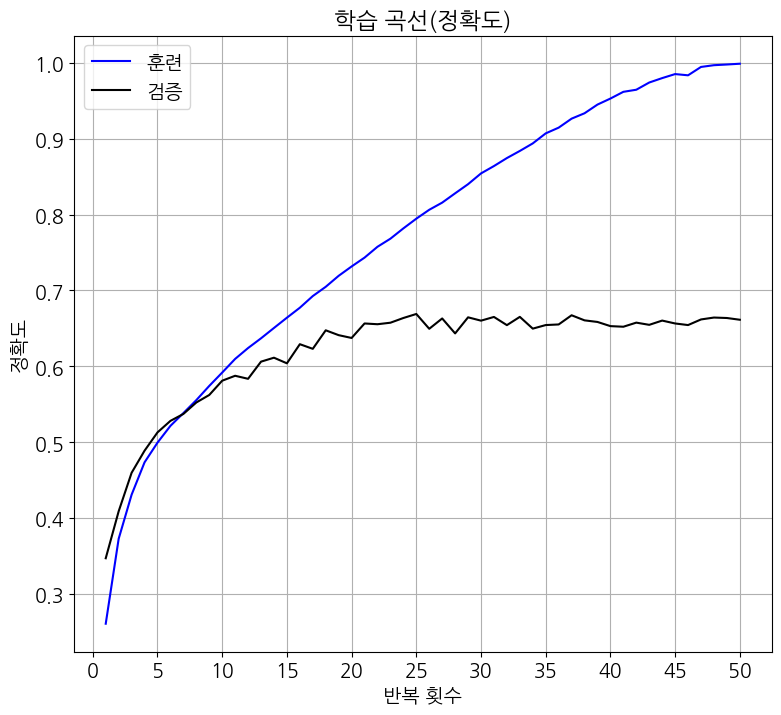

In [ ]:
evaluate_history(history2)

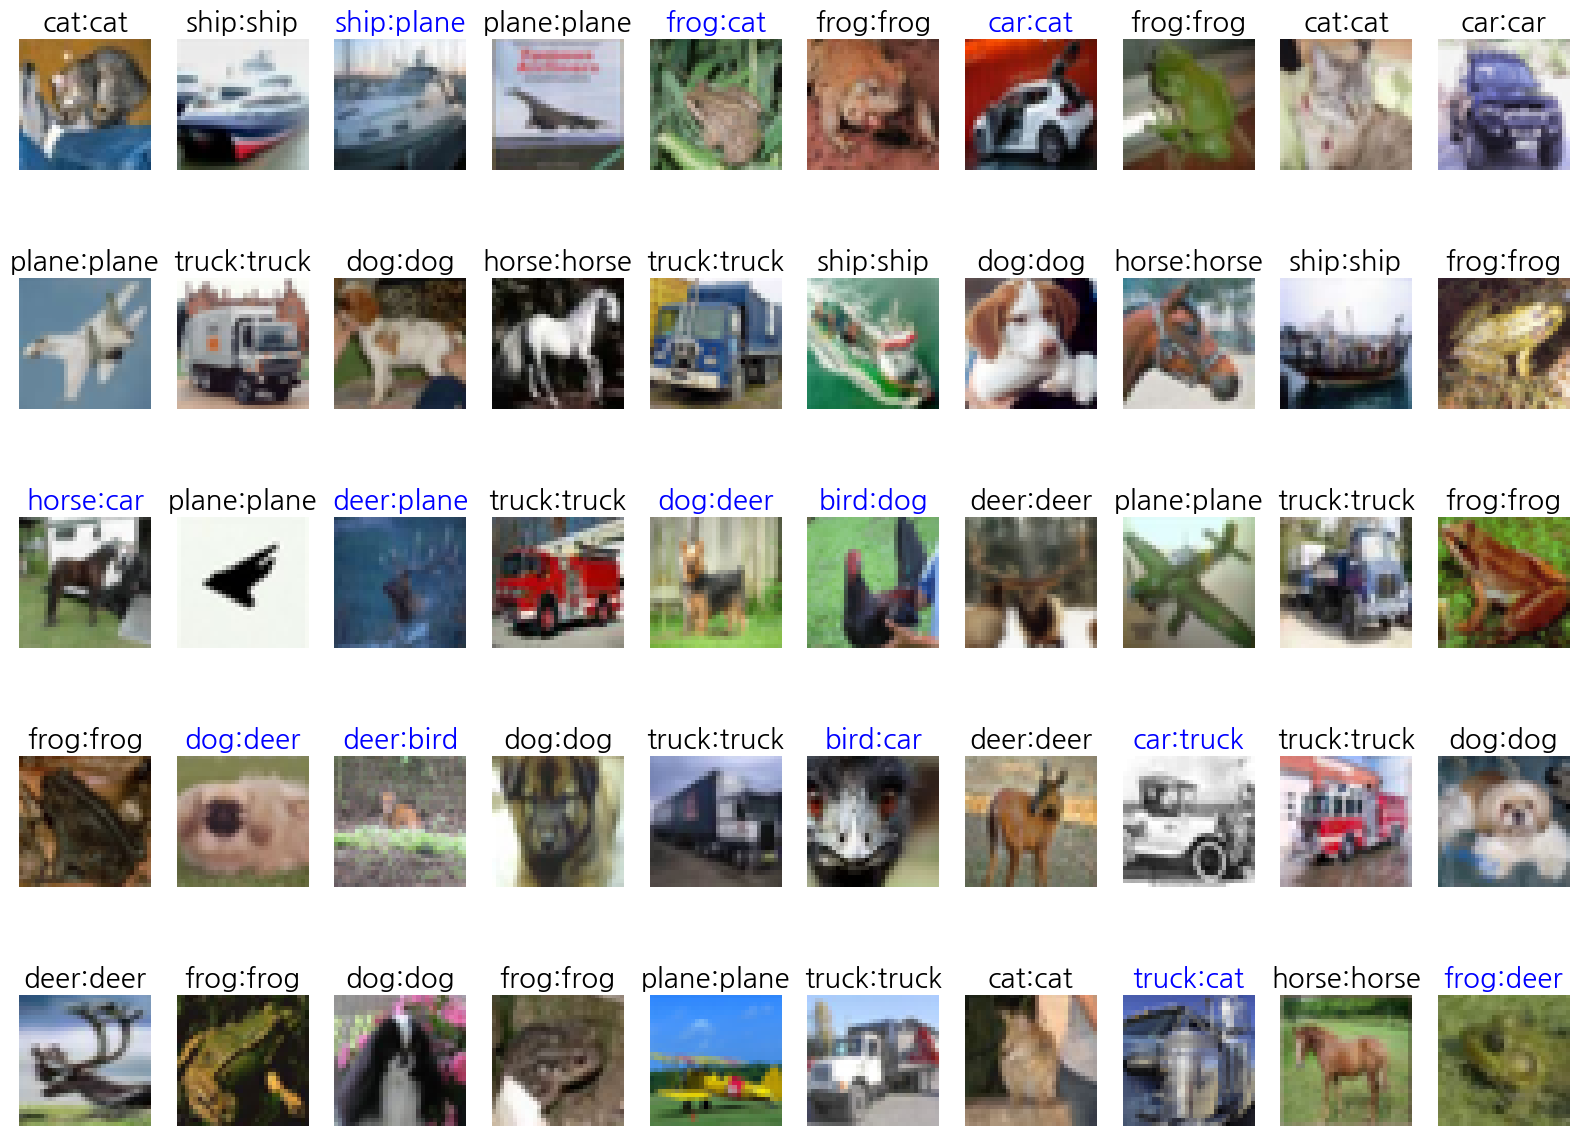

In [ ]:
# 처음 50 개 데이터 표시
show_images_labels(test_loader2, classes, net, device)

텐서 변환 연습

In [ ]:
이미지 = np.array([[[0,0,1], [0,1,0], [1,0,0]]])
이미지_torch = torch.tensor(이미지).float()

이미지_torch.shape # 3차원

torch.Size([1, 3, 3])

In [ ]:
이미지_torch.view(-1) # 1차원

tensor([0., 0., 1., 0., 1., 0., 1., 0., 0.])

In [ ]:
이미지_torch.permute(1,2,0).shape # 위에서 했던 순서바꾸는거 torch버전 permute

torch.Size([3, 3, 1])

In [ ]:
이미지_torch.permute(1,2,0)

tensor([[[0.],
         [0.],
         [1.]],

        [[0.],
         [1.],
         [0.]],

        [[1.],
         [0.],
         [0.]]])

In [ ]:
이미지_torch.permute(1,2,0).reshape(-1,3).shape # 이런걸 좀 해봐야 함.

torch.Size([3, 3])

In [ ]:
이미지_torch.ndim

3

In [ ]:
# EOS